# Assignment 3



Question 1 - Least Square Approximation

In [14]:
import numpy as np
import matplotlib.pyplot as plt

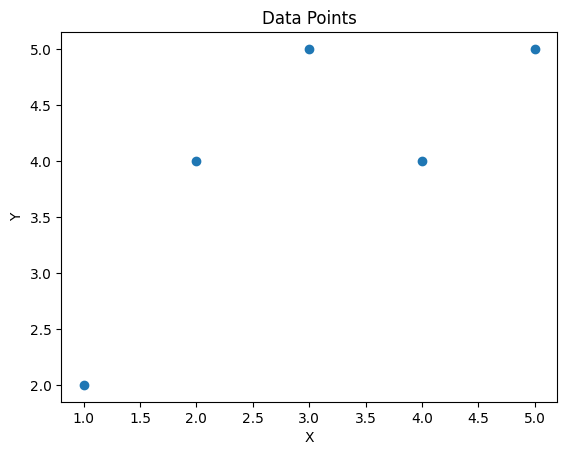

In [15]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Data Points")
plt.show()

In [16]:
x_mean = np.mean(x)
y_mean = np.mean(y)

m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
b = y_mean - m * x_mean

print("Slope:", m)
print("Intercept:", b)

Slope: 0.6
Intercept: 2.2


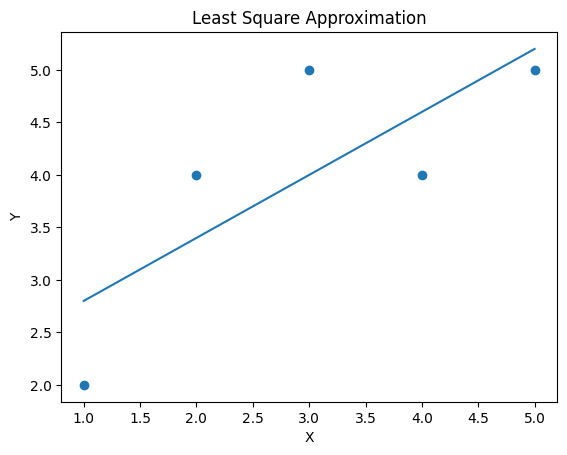

In [17]:
y_pred = m * x + b

plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Square Approximation")
plt.show()

Question 2 - Gradient Descent

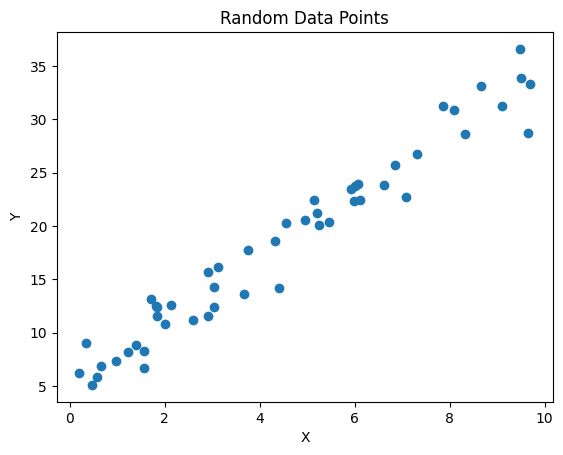

In [18]:
np.random.seed(42)

x = np.random.rand(50) * 10
y = 3 * x + 5 + np.random.randn(50) * 2

plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Random Data Points")
plt.show()

In [19]:
m = 0
b = 0

learning_rate = 0.01
iterations = 1000

n = len(x)

for i in range(iterations):
    y_pred = m * x + b

    dm = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)

    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Slope:", m)
print("Intercept:", b)

Slope: 2.957784597317004
Intercept: 5.177982847588438


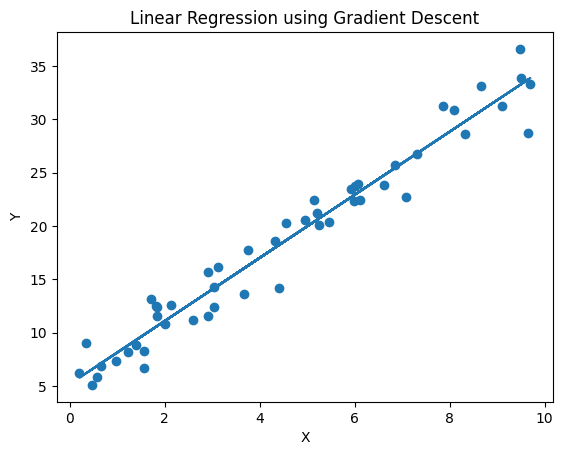

In [20]:
y_pred = m * x + b

plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression using Gradient Descent")
plt.show()

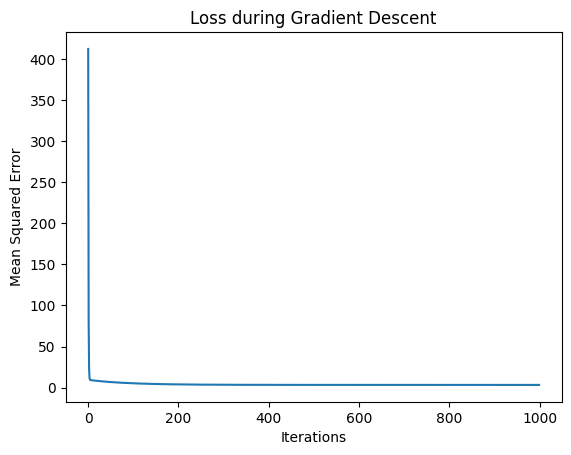

Final Slope: 2.957784597317004
Final Intercept: 5.177982847588438


In [21]:
m = 0
b = 0

learning_rate = 0.01
iterations = 1000
n = len(x)

loss_history = []

for i in range(iterations):
    y_pred = m * x + b

    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)

    dm = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)

    m = m - learning_rate * dm
    b = b - learning_rate * db

plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.title("Loss during Gradient Descent")
plt.show()

print("Final Slope:", m)
print("Final Intercept:", b)

Question 3 - Linear Regression on Titanic Dataset

In [24]:
import pandas as pd
titanic = pd.read_csv("train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
print("Shape:", titanic.shape)
print("\nData Types:")
print(titanic.dtypes)

print("\nMissing Values:")
print(titanic.isnull().sum())

Shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [26]:
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [27]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

print(titanic.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [28]:
titanic = pd.get_dummies(titanic, columns=['Sex', 'Embarked'], drop_first=True)

titanic.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [29]:
print(titanic.dtypes)
print("\nMissing Values:")
print(titanic.isnull().sum())

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

Missing Values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [30]:
X = titanic.drop(columns=['Survived'])
y = titanic['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 8)
Target shape: (891,)


In [31]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].values
X_test = X.iloc[test_indices].values

y_train = y.iloc[train_indices].values
y_test = y.iloc[test_indices].values

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [33]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_std[X_std == 0] = 1

X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

print("Feature scaling completed.")

Feature scaling completed.


In [34]:
weights = np.zeros(X_train.shape[1])
bias = 0

learning_rate = 0.01
iterations = 2000

n = len(X_train)

for i in range(iterations):
    y_pred = np.dot(X_train, weights) + bias

    dw = (-2 / n) * np.dot(X_train.T, (y_train - y_pred))
    db = (-2 / n) * np.sum(y_train - y_pred)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

print("Weights:", weights)
print("Bias:", bias)

Weights: [-0.14474636 -0.08821496 -0.05641366 -0.00890193  0.02043953 -0.23613442
 -0.00641912 -0.02178238]
Bias: 0.3890449438202234


In [35]:
y_pred = np.dot(X_test, weights) + bias

print("First 10 Actual Values:")
print(y_test[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred[:10])

First 10 Actual Values:
[0 0 1 1 1 0 1 1 0 0]

First 10 Predicted Values:
[0.30064025 0.02630256 0.35116663 0.59627427 0.83003056 0.04952469
 0.84746447 0.41896794 0.28082091 0.34722132]


In [36]:
mse = np.mean((y_test - y_pred) ** 2)

ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_residual = np.sum((y_test - y_pred) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.13860097827311574
R² Score: 0.40068637721337375


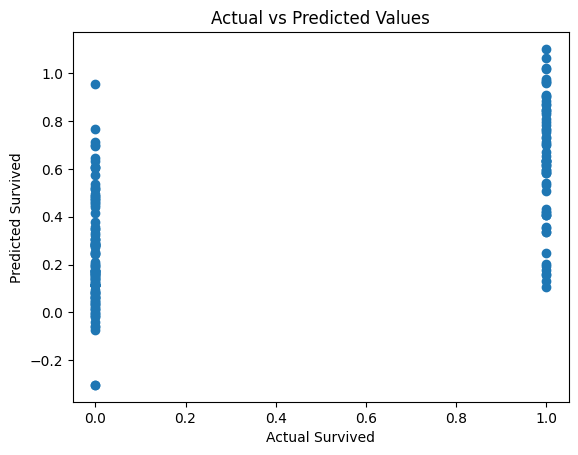

In [37]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Survived")
plt.ylabel("Predicted Survived")
plt.title("Actual vs Predicted Values")
plt.show()